# Storm Trajectory + Intensity Prediction — Training (Warmup Windows)

Full training pipeline with **left-zero-padding + attention masking**, which allows the model
to make predictions from the very first storm timestep (not just after 8 observations).

Key differences vs the original `model_transformer.ipynb`:
- `_make_windows()` now generates **warmup windows** for the first 7 timesteps of every storm
- Each window carries a `mask` tensor (`True` = padded, `False` = real observation)
- `StormTransformer.forward()` accepts an optional `mask` and passes it to `TransformerEncoder` as `src_key_padding_mask`
- `scaler_X` is fit on **real rows only** (not zero-padded positions) to avoid bias
- Padded positions are **re-zeroed** after scaling
- Training/validation loops unpack 4-item batches `(X, y, ctx, mask)`

Sections:
1. Environment setup
2. Build datasets
3. Model architecture
4. GPU check
5. Training
6. Evaluation
7. Comparison vs Random Forest baseline
8. Trajectory plots
9. Loss curves
10. Epoch log

## 1 · Environment Setup

In [1]:
import os
import sys
import json
from pathlib import Path
from dotenv import load_dotenv

PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / ".env")

assert "DATABASE_URL" in os.environ, (
    "DATABASE_URL not found — add it to .env at the project root."
)

print("DATABASE_URL loaded successfully.")

DATABASE_URL loaded successfully.


## 2 · Build Datasets

In [ ]:
import numpy as np
import torch
from src.model.dataset import build_datasets, SEQ_LEN, N_FEATURES, N_ROLLOUT_STEPS

# save_scalers=False here — train() in Section 5 will save the definitive scalers
train_ds, val_ds, test_ds, scaler_X, scaler_y = build_datasets(save_scalers=False)

# Shape checks — dataset now returns 4 items (X, y, ctx, mask)
X_sample, y_sample, ctx_sample, mask_sample = train_ds[0]

assert X_sample.shape    == (SEQ_LEN, N_FEATURES),   f"X shape wrong: {X_sample.shape}"
assert y_sample.shape    == (N_ROLLOUT_STEPS, 3),    f"y shape wrong: {y_sample.shape}"
assert ctx_sample.shape  == (2,),                    f"ctx shape wrong: {ctx_sample.shape}"
assert mask_sample.shape == (SEQ_LEN,),              f"mask shape wrong: {mask_sample.shape}"
assert mask_sample.dtype == torch.bool,              f"mask dtype wrong: {mask_sample.dtype}"

print(f"Train windows : {len(train_ds):,}")
print(f"Val windows   : {len(val_ds):,}")
print(f"Test windows  : {len(test_ds):,}")
print()
print(f"X shape    : {tuple(X_sample.shape)}   — [SEQ_LEN={SEQ_LEN}, N_FEATURES={N_FEATURES}]")
print(f"y shape    : {tuple(y_sample.shape)}  — [N_ROLLOUT_STEPS={N_ROLLOUT_STEPS}, N_TARGETS=3]")
print(f"ctx shape  : {tuple(ctx_sample.shape)}        — (basin_id, season_norm)")
print(f"mask shape : {tuple(mask_sample.shape)}        — bool, True=padded position")
print()
print("First warmup window mask (predicting from obs_0 only):")
print(f"  {mask_sample.tolist()}")
print(f"  → {mask_sample.sum().item()} padded, {(~mask_sample).sum().item()} real")

In [4]:
# Scaler sanity: real (non-padded) rows should be ~N(0,1)
real_X = train_ds.X[~train_ds.mask].numpy()   # [M, N_FEATURES]
mean_abs = abs(real_X.mean())
print(f"Scaler sanity (real rows only)")
print(f"  Global mean    : {real_X.mean():.4f}  (expect ≈ 0)")
print(f"  Avg feature std: {real_X.std(axis=0).mean():.4f}  (expect ≈ 1)")
assert mean_abs < 0.5, f"Scaling looks off — mean_abs={mean_abs:.4f}"

# Padded rows must be exactly 0
pad_X = train_ds.X[train_ds.mask].numpy()
assert pad_X.max() == 0.0 and pad_X.min() == 0.0, "Padded rows are not zero!"
print(f"  Padded rows    : {len(pad_X):,} timesteps — all zeros")

Scaler sanity (real rows only)
  Global mean    : -0.0000  (expect ≈ 0)
  Avg feature std: 0.9372  (expect ≈ 1)
  Padded rows    : 56,290 timesteps — all zeros


## 3 · Model Architecture

In [5]:
from src.model.transformer import StormTransformer, count_parameters
from src.model.dataset import N_BASINS

model = StormTransformer(n_features=N_FEATURES, n_basins=N_BASINS)
print(model)
print(f"\nTotal trainable parameters: {count_parameters(model):,}")

# Forward-pass sanity: full window
dummy_x    = torch.randn(32, SEQ_LEN, N_FEATURES)
dummy_ctx  = torch.zeros(32, 2)
dummy_mask = torch.zeros(32, SEQ_LEN, dtype=torch.bool)  # no padding
out = model(dummy_x, dummy_ctx, mask=dummy_mask)
assert out.shape == (32, 3), f"Expected (32, 3), got {out.shape}"
print(f"\nFull window  : input {tuple(dummy_x.shape)} → output {tuple(out.shape)}  ✓")

# Warmup window: 7 padded + 1 real (first storm timestep)
warmup_mask = torch.ones(32, SEQ_LEN, dtype=torch.bool)
warmup_mask[:, -1] = False
out_w = model(dummy_x, dummy_ctx, mask=warmup_mask)
assert out_w.shape == (32, 3)
print(f"Warmup window: 7 padded + 1 real → output {tuple(out_w.shape)}  ✓")

StormTransformer(
  (input_proj): Linear(in_features=16, out_features=64, bias=True)
  (pos_emb): Embedding(8, 64)
  (basin_emb): Embedding(7, 64)
  (season_proj): Linear(in_features=1, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (

## 4 · GPU Check

In [6]:
cuda_available = torch.cuda.is_available()
print(f"CUDA available : {cuda_available}")

if cuda_available:
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU            : {gpu_name}")
    print(f"VRAM           : {vram_gb:.1f} GB")
    x = torch.randn(4, SEQ_LEN, N_FEATURES).cuda()
    print(f"Tensor device  : {x.device}")
    del x
    torch.cuda.empty_cache()
    print("\nTraining will use GPU.")
else:
    print("\nNo CUDA GPU detected — training will use CPU.")

CUDA available : True
GPU            : NVIDIA GeForce RTX 5060
VRAM           : 8.0 GB
Tensor device  : cuda:0

Training will use GPU.


## 5 · Training

In [7]:
from src.model.train import train

model, training_log = train()
print(f"\nTraining complete. Epochs run: {len(training_log)}")

Device: cuda — NVIDIA GeForce RTX 5060 (8.0 GB VRAM)
Loading data from database…


C:\Users\Admin\Desktop\Predict_storm_trajectory\src\model\dataset.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(SQL, conn)


  Loaded 132,646 rows, 2,343 unique storms.
  Train storms: 2,019 | Val: 158 | Test: 166
  Windows — Train: 111,255 | Val: 8,509 | Test: 8,198
  Train basin distribution: {'EP': 2464, 'NI': 70, 'WP': 108721}
  Val basin distribution: {'EP': 94, 'WP': 8415}
  Test basin distribution: {'EP': 136, 'WP': 8062}
  Scalers saved to C:\Users\Admin\Desktop\Predict_storm_trajectory\models/
Parameters: 156,483
AMP enabled    : False
Epoch 001/100 | Train loss: 35.15 km | Val loss: 16.51 km | Val Haversine: 14.9 km | rollout_λ: 0.00 | LR: 1.000e-03 | Time: 7.4s
  --> Saved checkpoint (val loss 16.51 km)
Epoch 002/100 | Train loss: 14.08 km | Val loss: 10.39 km | Val Haversine: 9.9 km | rollout_λ: 0.00 | LR: 9.998e-04 | Time: 6.7s
  --> Saved checkpoint (val loss 10.39 km)
Epoch 003/100 | Train loss: 11.36 km | Val loss: 8.52 km | Val Haversine: 8.1 km | rollout_λ: 0.00 | LR: 9.990e-04 | Time: 6.7s
  --> Saved checkpoint (val loss 8.52 km)
Epoch 004/100 | Train loss: 10.18 km | Val loss: 9.23 km | 

## 6 · Evaluation

In [8]:
import joblib
from src.model.evaluate import load_model, evaluate_test

MODELS_DIR = PROJECT_ROOT / "models"
scaler_X = joblib.load(MODELS_DIR / "scaler_X.pkl")
scaler_y = joblib.load(MODELS_DIR / "scaler_y.pkl")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_eval = load_model(device)

hav_km, wind_mae = evaluate_test(model_eval, test_ds, scaler_X, scaler_y, device)


=== Test Set Metrics ===
  Mean Haversine distance : 7.4 km
  Median Haversine        : 6.4 km
  Wind speed MAE          : 2.34 knots


In [9]:
# Percentile breakdown
print("Haversine distance percentiles (km)")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:>2} : {np.percentile(hav_km, p):.1f} km")
print(f"  max : {hav_km.max():.1f} km")

Haversine distance percentiles (km)
  p10 : 2.5 km
  p25 : 4.1 km
  p50 : 6.4 km
  p75 : 9.2 km
  p90 : 12.6 km
  p95 : 15.6 km
  p99 : 32.4 km
  max : 97.2 km


## 6b · Forecast Horizon Errors (24 h / 48 h)

Standard metric in tropical cyclone track forecasting literature.

- **24 h error** = autoregressive 8-step rollout (8 × 3 h)
- **48 h error** = autoregressive 16-step rollout (16 × 3 h)

For each valid starting position in every test storm, the model predicts one step at a time, feeding each prediction back as input for the next step. The Haversine distance between the final predicted position and the actual position is the forecast error.

In [ ]:
from src.model.dataset import _load_from_db, _engineer_features, FEATURE_COLS, N_FEATURES, SEQ_LEN, haversine_km

STEP_HOURS = 3                          # each model step = 3 h
HORIZONS   = {24: 24 // STEP_HOURS,    # 8 steps
              48: 48 // STEP_HOURS}     # 16 steps


def compute_multi_horizon_errors(model, scaler_X, scaler_y, device, horizons):
    """
    Roll out the model autoregressively up to max(horizons) steps for every
    valid starting position in every test storm (season >= 2020).

    Args:
        horizons : dict  {label_hours: n_steps}  e.g. {24: 8, 48: 16}

    Returns:
        dict {label_hours: np.ndarray of Haversine errors (km)}
    """
    max_steps = max(horizons.values())
    target_steps = set(horizons.values())

    df = _load_from_db()
    df = _engineer_features(df)
    test_storms = df[df["season"] >= 2020]["atcf_id"].unique()

    step_errors = {s: [] for s in target_steps}

    model.eval()
    with torch.no_grad():
        for sid in test_storms:
            storm = df[df["atcf_id"] == sid].reset_index(drop=True)
            if len(storm) < max_steps + 1:
                continue

            feats_raw  = storm[FEATURE_COLS].values.astype(np.float32)
            feats_norm = scaler_X.transform(feats_raw).astype(np.float32)

            basin_id    = int(storm["basin_id"].iloc[0])
            season_norm = float(storm["season_norm"].iloc[0])
            ctx = torch.tensor([[basin_id, season_norm]], dtype=torch.float32, device=device)

            for start in range(len(storm) - max_steps):
                # Build initial window ending at index 'start' (with warmup padding if needed)
                real_start = max(0, start + 1 - SEQ_LEN)
                window_raw = feats_norm[real_start : start + 1]
                real_len   = len(window_raw)
                pad_len    = SEQ_LEN - real_len
                if pad_len > 0:
                    pad        = np.zeros((pad_len, N_FEATURES), dtype=np.float32)
                    window_raw = np.concatenate([pad, window_raw], axis=0)

                win_t  = torch.tensor(window_raw, dtype=torch.float32, device=device).unsqueeze(0)
                mask_t = torch.tensor(
                    [True] * pad_len + [False] * real_len, device=device
                ).unsqueeze(0)

                cur_lat = float(feats_raw[start, 0])
                cur_lon = float(feats_raw[start, 1])

                for step in range(1, max_steps + 1):
                    pred_norm = model(win_t, ctx, mask=mask_t)          # [1, 3]
                    pred_raw  = scaler_y.inverse_transform(pred_norm.cpu().numpy())

                    d_lat = float(pred_raw[0, 0])
                    d_lon = float(pred_raw[0, 1])
                    wind  = float(pred_raw[0, 2])

                    cur_lat += d_lat
                    cur_lon += d_lon

                    # Build next normalised feature row (keep context features from last step)
                    X_last_raw      = scaler_X.inverse_transform(win_t[:, -1, :].cpu().numpy())
                    new_raw         = X_last_raw.copy()
                    new_raw[0, 0]   = cur_lat
                    new_raw[0, 1]   = cur_lon
                    new_raw[0, 2]   = d_lat
                    new_raw[0, 3]   = d_lon
                    new_raw[0, 7]   = wind
                    new_norm = torch.tensor(
                        scaler_X.transform(new_raw), dtype=torch.float32, device=device
                    )

                    # Shift window: drop oldest, append new step; mask is all-real after first real step
                    win_t  = torch.cat([win_t[:, 1:, :], new_norm.unsqueeze(1)], dim=1)
                    mask_t = torch.cat(
                        [mask_t[:, 1:], torch.zeros(1, 1, dtype=torch.bool, device=device)], dim=1
                    )

                    if step in target_steps:
                        true_lat = float(feats_raw[start + step, 0])
                        true_lon = float(feats_raw[start + step, 1])
                        err = haversine_km(
                            np.array([true_lat]), np.array([true_lon]),
                            np.array([cur_lat]),  np.array([cur_lon]),
                        )[0]
                        step_errors[step].append(err)

    return {hours: np.array(step_errors[n]) for hours, n in horizons.items()}


print("Computing 24 h / 48 h forecast errors (autoregressive rollout)…")
horizon_errors = compute_multi_horizon_errors(model_eval, scaler_X, scaler_y, device, HORIZONS)

for h, errs in horizon_errors.items():
    print(f"\n  {h}h forecast error  (n={len(errs):,} samples)")
    print(f"    Mean   : {errs.mean():.1f} km")
    print(f"    Median : {np.median(errs):.1f} km")

In [ ]:
# Horizon error summary table
rows = [{"Horizon": "3h  (direct, step-1)",
         "N samples": len(hav_km),
         "Mean (km)": round(float(hav_km.mean()), 1),
         "Median (km)": round(float(np.median(hav_km)), 1)}]

for h in sorted(horizon_errors):
    errs = horizon_errors[h]
    rows.append({"Horizon": f"{h}h (autoregressive rollout)",
                 "N samples": len(errs),
                 "Mean (km)": round(float(errs.mean()), 1),
                 "Median (km)": round(float(np.median(errs)), 1)})

display(pd.DataFrame(rows))

## 8 · Trajectory Plots

C:\Users\Admin\Desktop\Predict_storm_trajectory\src\model\dataset.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(SQL, conn)
c:\Users\Admin\anaconda3\envs\storm_trajectory\lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


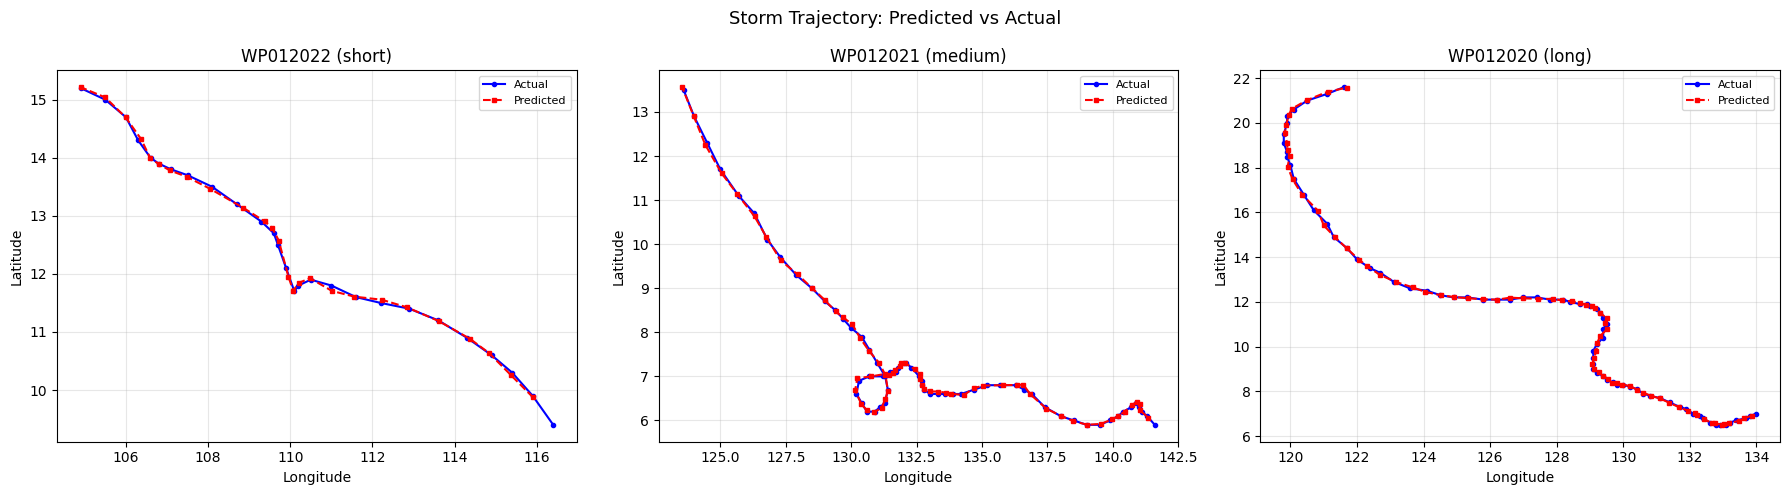

Trajectory plot saved to C:\Users\Admin\Desktop\Predict_storm_trajectory\models/trajectory_plots.png


In [11]:
from src.model.evaluate import plot_trajectories

plot_trajectories(scaler_X, scaler_y, device)

## 9 · Loss Curves

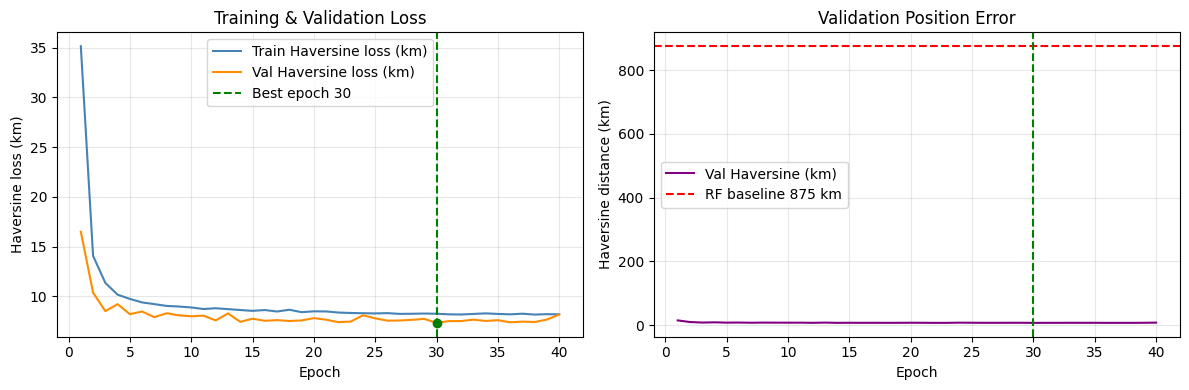

Loss curve saved to C:\Users\Admin\Desktop\Predict_storm_trajectory\models/loss_curves.png


In [12]:
from src.model.evaluate import plot_loss_curves

plot_loss_curves()

## 10 · Detailed Epoch Log

In [13]:
log_df = pd.DataFrame(training_log)
display(log_df)

best_row = log_df.loc[log_df["val_loss_km"].idxmin()]
print(f"\nBest epoch      : {int(best_row['epoch'])}")
print(f"  Val loss (km) : {best_row['val_loss_km']:.2f}")
print(f"  Val Haversine : {best_row['val_haversine_km']:.1f} km")

,epoch,train_loss_km,val_loss_km,val_haversine_km,rollout_lambda,lr
0,1,35.152073,16.508414,14.909550,0.000,0.001000
1,2,14.082168,10.385122,9.855562,0.000,0.001000
2,3,11.360627,8.524754,8.148258,0.000,0.000999
3,4,10.177784,9.226904,8.945264,0.000,0.000998
4,5,9.752911,8.220278,7.924276,0.000,0.000996
5,6,9.398877,8.485378,8.202266,0.000,0.000994
6,7,9.228416,7.918030,7.583074,0.000,0.000991
7,8,9.048284,8.315255,8.071099,0.000,0.000988
8,9,8.987507,8.100358,7.863126,0.000,0.000984
9,10,8.894903,8.010496,7.781140,0.000,0.000980



Best epoch      : 30
  Val loss (km) : 7.34
  Val Haversine : 7.1 km
